# 02c — Feature Importance Analysis & Cross-Method Comparison

Analyze feature importance across methods and compare results.

**Prerequisites:** Run notebooks 02a through 02b_method4 first.

In [1]:
# --- Shared Setup ---
# This notebook depends on artifacts saved by notebooks 02a through 02b_method4.

import sys
sys.path.insert(0, '..')

import os
import json
import time
import warnings
from pathlib import Path
from typing import TypedDict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cosine as cosine_dist
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore', category=FutureWarning)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from atdj.config import PROCESSED_DIR, DATA_DIR

# --- Load core artifacts from 02a ---
FEATURES_DIR = Path(PROCESSED_DIR) / 'features_exp'
df_merged = pd.read_pickle(FEATURES_DIR / 'df_merged.pkl')
print(f'Loaded df_merged: {df_merged.shape}')

import pickle
with open(FEATURES_DIR / 'feature_catalog.pkl', 'rb') as f:
    FEATURE_CATALOG = pickle.load(f)

ALL_FEATURE_NAMES = []
FEATURE_DESC_MAP = {}
for group, features in FEATURE_CATALOG.items():
    for fname, fdesc in features:
        ALL_FEATURE_NAMES.append(fname)
        FEATURE_DESC_MAP[fname] = fdesc
AVAILABLE_FEATURES = [f for f in ALL_FEATURE_NAMES if f in df_merged.columns]

with open(FEATURES_DIR / 'feature_prompt.txt', encoding='utf-8') as f:
    FEATURE_PROMPT = f.read()

print(f'Feature catalog: {len(AVAILABLE_FEATURES)} features across {len(FEATURE_CATALOG)} groups')

# --- Load TARGET_FEATURES and scaling from 02b_method4 ---
tf_path = FEATURES_DIR / 'target_features.json'
if tf_path.exists():
    with open(tf_path, encoding='utf-8') as f:
        TARGET_FEATURES = json.load(f)
    print(f'Loaded TARGET_FEATURES: {len(TARGET_FEATURES)} features')
else:
    TARGET_FEATURES = []
    print('WARNING: target_features.json not found \u2014 run notebook 02b_method4 first')

scaling_path = FEATURES_DIR / 'feature_scaling.json'
if scaling_path.exists():
    with open(scaling_path, encoding='utf-8') as f:
        scaling = json.load(f)
    FEATURE_MINS = np.array(scaling['feature_mins'], dtype=np.float32)
    FEATURE_MAXS = np.array(scaling['feature_maxs'], dtype=np.float32)
    FEATURE_RANGES = np.array(scaling['feature_ranges'], dtype=np.float32)
else:
    FEATURE_MINS = FEATURE_MAXS = FEATURE_RANGES = np.array([])

# Feature-to-group mapping for coloring plots
feature_to_group = {}
for group, features in FEATURE_CATALOG.items():
    for fname, _ in features:
        feature_to_group[fname] = group
group_colors = {
    'rhythm': '#e41a1c', 'energy': '#ff7f00', 'mood': '#984ea3',
    'spectral': '#377eb8', 'timbre': '#4daf4a', 'harmony': '#a65628',
    'danceability': '#f781bf', 'voice': '#999999', 'metadata': '#666666',
    'texture': '#e6ab02',
}

Loaded df_merged: (294, 94)
Feature catalog: 45 features across 9 groups


In [2]:
# --- Sentence-Transformers Setup ---
try:
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True
    sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
    print('sentence-transformers loaded')
except ImportError:
    SBERT_AVAILABLE = False
    sbert_model = None
    print('sentence-transformers not available')

# --- CLAP Setup ---
clap_model = None
clap_processor = None
try:
    from transformers import ClapModel, ClapProcessor
    import librosa
    CLAP_AVAILABLE = True
    clap_model = ClapModel.from_pretrained('laion/larger_clap_music_and_speech')
    clap_processor = ClapProcessor.from_pretrained('laion/larger_clap_music_and_speech')
    clap_model.eval()
    print('CLAP model loaded')
except ImportError:
    CLAP_AVAILABLE = False
    print('CLAP not available')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


sentence-transformers loaded


Loading weights:   0%|          | 0/555 [00:00<?, ?it/s]

CLAP model loaded


In [3]:
# --- Load small model from 02b_method4 (COMMENTED OUT — model not trained yet) ---
# F = len(TARGET_FEATURES) if TARGET_FEATURES else 0
# class PromptToFeatureModel(nn.Module): ...
# model = None
# model_path = FEATURES_DIR / 'prompt_to_feature_model.pt'
# ... (see 02d for full model definition)

print('Small model section skipped — not trained yet')

Small model section skipped — not trained yet


In [4]:
# Standardized output format — all methods return this structure
class SongMatch(TypedDict):
    filename: str
    score: float              # 0-1, higher = better match
    matched_features: dict    # feature_name: actual_value
    explanation: str          # why this song matches

class MatchResult(TypedDict):
    prompt: str
    method: str               # 'clap' | 'cot_llm_a' | 'sbert_direction' | 'small_model'
    top_k_songs: list         # list of SongMatch
    bottom_k_songs: list      # worst-matching songs for human validation
    feature_ranges_used: dict # feature_name: {min, max, direction}
    metadata: dict            # method-specific (model name, latency, etc.)


# Test prompts used across all methods
TEST_PROMPTS = [
    'energetic tango with strong rhythm for experienced dancers',
    'melancholic and slow, perfect for a late-night vals',
    'bright and cheerful milonga with clear melody',
    'dramatic tango with heavy bandoneon and dark mood',
    'smooth and relaxed, good for warming up the floor',
    'classic golden-age tango from the 40s, warm and nostalgic',
    'a lively vals from the 50s with a strong orchestra',
    'need a cortina — something upbeat and non-tango to reset the floor',
]

TOP_K = 10
BOTTOM_K = 5  # worst matches for human validation

# Collect all results here for cross-method comparison
ALL_RESULTS: dict[str, list[MatchResult]] = {}  # method_name -> list of results

print(f'Test prompts: {len(TEST_PROMPTS)}')
print(f'Top-K: {TOP_K}')
for i, p in enumerate(TEST_PROMPTS, 1):
    print(f'  {i}. "{p}"')

Test prompts: 8
Top-K: 10
  1. "energetic tango with strong rhythm for experienced dancers"
  2. "melancholic and slow, perfect for a late-night vals"
  3. "bright and cheerful milonga with clear melody"
  4. "dramatic tango with heavy bandoneon and dark mood"
  5. "smooth and relaxed, good for warming up the floor"
  6. "classic golden-age tango from the 40s, warm and nostalgic"
  7. "a lively vals from the 50s with a strong orchestra"
  8. "need a cortina — something upbeat and non-tango to reset the floor"


In [5]:
# --- Load results from all method notebooks ---
results_dir = Path(PROCESSED_DIR) / 'features_exp'

for rfile in sorted(results_dir.glob('*_results.json')):
    method = rfile.stem.replace('_results', '')
    with open(rfile, encoding='utf-8') as f:
        ALL_RESULTS[method] = json.load(f)
    print(f'Loaded {method}: {len(ALL_RESULTS[method])} results')

print(f'\nMethods loaded: {list(ALL_RESULTS.keys())}')

# Load feature embeddings for Method 2B Stage 1 (if sbert available)
feature_embeddings = {}
if SBERT_AVAILABLE:
    for group, features in FEATURE_CATALOG.items():
        for fname, fdesc in features:
            if fname in df_merged.columns:
                feature_embeddings[fname] = sbert_model.encode([fdesc])[0]
    print(f'Computed {len(feature_embeddings)} feature embeddings')

all_training = bool(ALL_RESULTS.get('small_model'))  # flag for permutation importance

Loaded clap: 8 results
Loaded cot_llm_a: 8 results
Loaded sbert_direction: 8 results

Methods loaded: ['clap', 'cot_llm_a', 'sbert_direction']


Computed 45 feature embeddings


---
## 1. Feature Importance Analysis

Which features actually matter most for text-prompt-driven song matching? We analyze this from multiple angles:
- **1a.** Feature selection frequency across feature-selecting methods
- **1b.** ~~Small model mask weights~~ (skipped — model not trained yet)
- **1c.** CLAP embedding decomposition
- **1d.** Permutation importance (model-agnostic)
- **1e.** Aggregated feature importance leaderboard

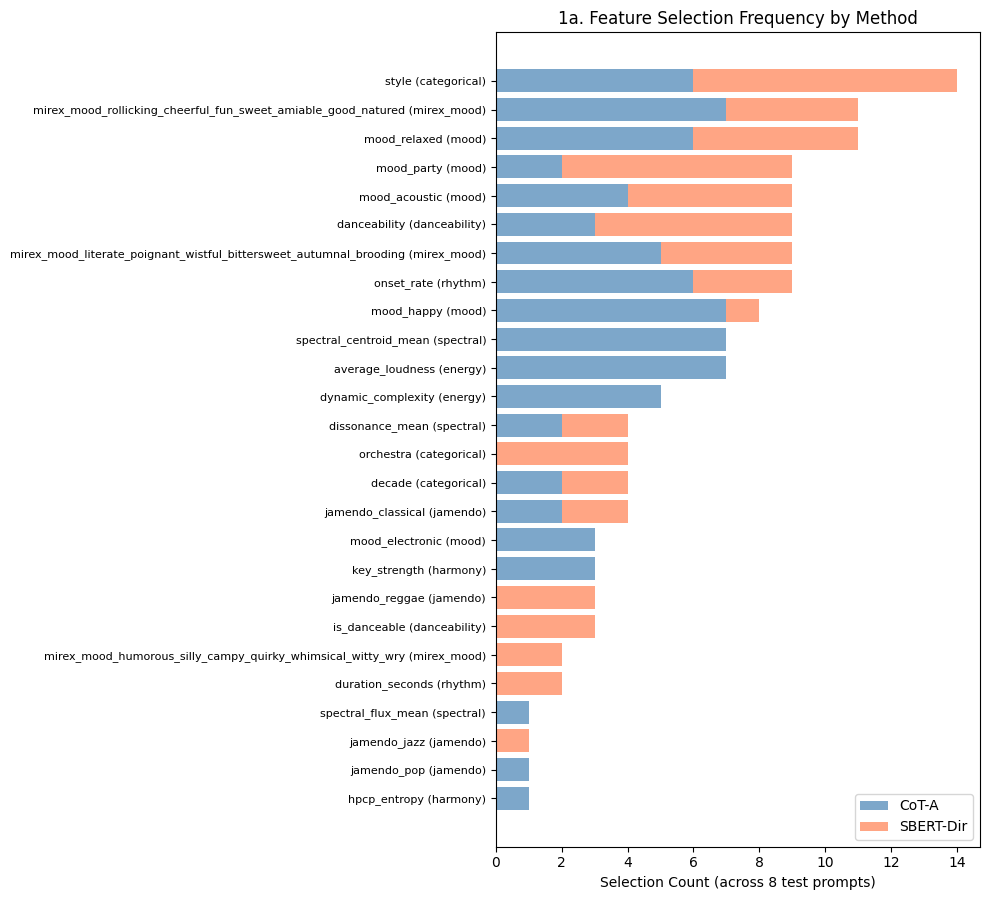

In [6]:
# --- 1a. Feature Selection Frequency (from feature-selecting methods) ---
# CLAP is excluded because it uses embedding similarity, not explicit feature selection.

def count_feature_selections(results: list[MatchResult]) -> dict[str, int]:
    """Count how often each feature is selected across all prompts."""
    counts = {}
    for result in results:
        for fname in result.get('feature_ranges_used', {}):
            counts[fname] = counts.get(fname, 0) + 1
    return counts

# Count selections per method
method_counts = {}  # method_name -> {feature: count}

# CoT LLM Method A
cot_a_counts = count_feature_selections(ALL_RESULTS.get('cot_llm_a', []))
if cot_a_counts:
    method_counts['CoT-A'] = cot_a_counts

# SBERT Direction
sbert_dir_counts = count_feature_selections(ALL_RESULTS.get('sbert_direction', []))
if sbert_dir_counts:
    method_counts['SBERT-Dir'] = sbert_dir_counts

# Combine and plot
all_features_seen = set()
for counts in method_counts.values():
    all_features_seen.update(counts.keys())

all_feature_counts = {}
for fname in all_features_seen:
    row = {m: counts.get(fname, 0) for m, counts in method_counts.items()}
    row['total'] = sum(row.values())
    all_feature_counts[fname] = row

if all_feature_counts:
    df_counts = pd.DataFrame(all_feature_counts).T.sort_values('total', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(df_counts) * 0.35)))
    y = range(len(df_counts))
    method_colors = ['steelblue', 'coral', 'mediumseagreen', 'goldenrod']
    left = np.zeros(len(df_counts))
    for i, method_name in enumerate(method_counts.keys()):
        vals = df_counts[method_name].values
        ax.barh(y, vals, left=left, label=method_name,
                color=method_colors[i % len(method_colors)], alpha=0.7)
        left += vals
    ax.set_yticks(y)
    ax.set_yticklabels([f'{name} ({feature_to_group.get(name, "?")})' for name in df_counts.index],
                       fontsize=8)
    ax.set_xlabel(f'Selection Count (across {len(TEST_PROMPTS)} test prompts)')
    ax.set_title('1a. Feature Selection Frequency by Method')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No feature-selecting methods have results yet')

In [7]:
# --- 1b. Small Model Mask Analysis (SKIPPED — model not trained yet) ---
# Uncomment when 02d small model is trained and small_model results exist.
# See previous version of this notebook for full mask analysis code.

print('1b. Small model mask analysis skipped — model not trained yet')

1b. Small model mask analysis skipped — model not trained yet


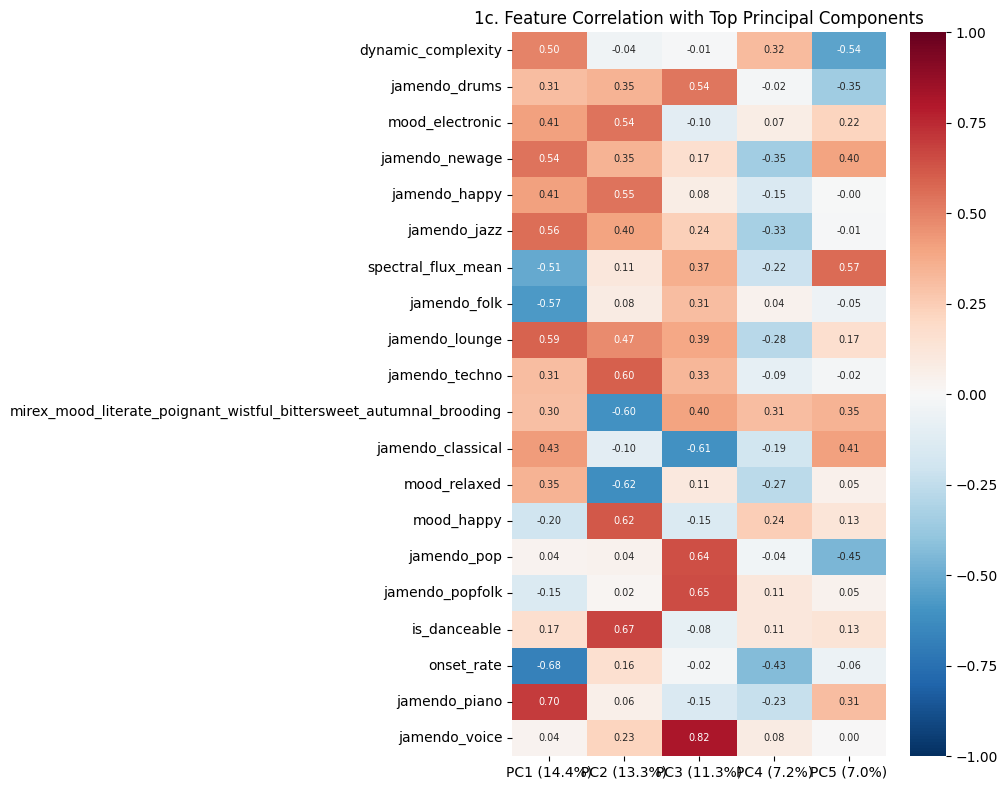

Top 10 features by max |correlation| with PCs:
  jamendo_voice                        max|r|=0.8166
  jamendo_piano                        max|r|=0.7014
  onset_rate                           max|r|=0.6795
  is_danceable                         max|r|=0.6730
  jamendo_popfolk                      max|r|=0.6531
  jamendo_pop                          max|r|=0.6447
  mood_happy                           max|r|=0.6239
  mood_relaxed                         max|r|=0.6231
  jamendo_classical                    max|r|=0.6081
  mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding  max|r|=0.6026


In [8]:
# --- 1c. CLAP Embedding Decomposition ---
# Analyze which extracted features correlate with CLAP's latent space

def encode_features_proxy(df: pd.DataFrame, feature_cols: list[str]) -> np.ndarray:
    """Fallback: build normalized feature vectors when audio files are unavailable.
    Returns (N, D) array where D = len(feature_cols)."""
    feat_df = df[feature_cols].copy()
    feat_df = feat_df.fillna(feat_df.mean())
    feat_df = feat_df.dropna(axis=1)
    scaler = StandardScaler()
    return scaler.fit_transform(feat_df)


def encode_text_clap(prompts: list[str], model, processor) -> np.ndarray:
    """Encode text prompts using CLAP text encoder. Returns (N, D) array."""
    inputs = processor(text=prompts, return_tensors='pt', padding=True, truncation=True)
    with torch.no_grad():
        text_features = model.get_text_features(**inputs)
    out = text_features if isinstance(text_features, torch.Tensor) else text_features.pooler_output
    return out.cpu().numpy()


if CLAP_AVAILABLE and ALL_RESULTS.get('clap') and clap_model is not None:
    from sklearn.decomposition import PCA

    # Get feature proxy embeddings
    numeric_features = [f for f in AVAILABLE_FEATURES
                       if f in df_merged.columns and df_merged[f].dtype in ['float64', 'float32', 'int64']]
    feat_df_raw = df_merged[numeric_features].copy().fillna(df_merged[numeric_features].mean()).dropna(axis=1)
    numeric_features = list(feat_df_raw.columns)
    feat_matrix = encode_features_proxy(df_merged, numeric_features)

    # Encode test prompts with CLAP
    text_embeds = encode_text_clap(TEST_PROMPTS, clap_model, clap_processor)

    # PCA on the feature matrix
    pca = PCA(n_components=min(10, *feat_matrix.shape))
    feat_pcs = pca.fit_transform(feat_matrix)

    # Correlate each original feature with top PCs
    n_pcs = min(5, feat_pcs.shape[1])
    corr_matrix = np.zeros((len(numeric_features), n_pcs))
    for i, fname in enumerate(numeric_features):
        for j in range(n_pcs):
            corr_matrix[i, j] = np.corrcoef(feat_matrix[:, i], feat_pcs[:, j])[0, 1]

    max_corr_per_feature = np.max(np.abs(corr_matrix), axis=1)
    top_20_idx = np.argsort(max_corr_per_feature)[-20:]

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr_matrix[top_20_idx],
        yticklabels=[numeric_features[i] for i in top_20_idx],
        xticklabels=[f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})' for i in range(n_pcs)],
        cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax,
        annot=True, fmt='.2f', annot_kws={'size': 7}
    )
    ax.set_title('1c. Feature Correlation with Top Principal Components')
    plt.tight_layout()
    plt.show()

    print(f'Top 10 features by max |correlation| with PCs:')
    for idx in top_20_idx[-10:][::-1]:
        print(f'  {numeric_features[idx]:35s}  max|r|={max_corr_per_feature[idx]:.4f}')
else:
    print('1c. CLAP decomposition skipped — CLAP not available or no CLAP results')

Computing permutation importance (this may take a minute)...
  Prompt 1/8: "energetic tango with strong rhythm for e..."


  Prompt 2/8: "melancholic and slow, perfect for a late..."


  Prompt 3/8: "bright and cheerful milonga with clear m..."


  Prompt 4/8: "dramatic tango with heavy bandoneon and ..."


  Prompt 5/8: "smooth and relaxed, good for warming up ..."


  Prompt 6/8: "classic golden-age tango from the 40s, w..."


  Prompt 7/8: "a lively vals from the 50s with a strong..."


  Prompt 8/8: "need a cortina — something upbeat and no..."


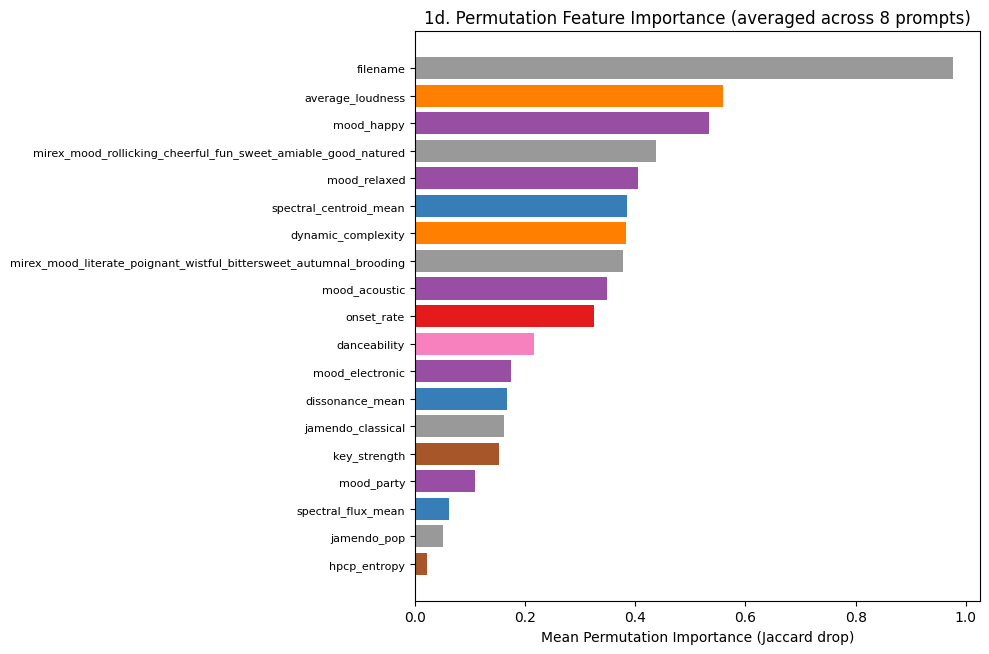

In [9]:
# --- 1d. Permutation Importance (model-agnostic) ---
# For each feature: shuffle its values, re-run ranking, measure how much top-K changes.
# If shuffling a feature causes big changes -> that feature is important.

def permutation_importance(rank_fn, df: pd.DataFrame, prompt: str,
                           features_to_test: list[str], top_k: int = 10,
                           n_repeats: int = 5) -> dict[str, float]:
    """Compute permutation importance for a ranking function.
    For each feature: shuffle it, re-run ranking, measure Jaccard drop from baseline."""
    baseline_result = rank_fn(prompt, df)
    baseline_songs = set(s['filename'] for s in baseline_result['top_k_songs'][:top_k])

    importance = {}
    rng = np.random.RandomState(42)

    for fname in features_to_test:
        if fname not in df.columns:
            importance[fname] = 0.0
            continue

        drops = []
        for _ in range(n_repeats):
            df_shuffled = df.copy()
            df_shuffled[fname] = rng.permutation(df_shuffled[fname].values)
            shuffled_result = rank_fn(prompt, df_shuffled)
            shuffled_songs = set(s['filename'] for s in shuffled_result['top_k_songs'][:top_k])

            if len(baseline_songs | shuffled_songs) > 0:
                jaccard = len(baseline_songs & shuffled_songs) / len(baseline_songs | shuffled_songs)
            else:
                jaccard = 1.0
            drops.append(1.0 - jaccard)  # importance = how much the ranking changed

        importance[fname] = np.mean(drops)

    return importance


def score_songs_by_ranges(df: pd.DataFrame, feature_ranges: dict) -> pd.Series:
    """Score each song by how well it fits the predicted feature ranges.
    Score per feature: 1.0 if value in [min,max], linear decay outside.
    Final score: weighted average across selected features."""
    scores = pd.Series(0.0, index=df.index)
    total_weight = 0.0

    for fname, spec in feature_ranges.items():
        if fname not in df.columns:
            continue
        col = df[fname]
        if col.dtype not in ['float64', 'float32', 'int64']:
            continue

        fmin = spec.get('min', col.min())
        fmax = spec.get('max', col.max())
        weight = spec.get('weight', 1.0)
        total_weight += weight

        range_width = fmax - fmin
        if range_width <= 0:
            range_width = 0.01

        below = ((fmin - col) / range_width).clip(lower=0)
        above = ((col - fmax) / range_width).clip(lower=0)
        feat_score = (1.0 - below - above).clip(lower=0)
        scores += weight * feat_score

    if total_weight > 0:
        scores /= total_weight

    return scores


def _make_range_ranker(feature_ranges: dict, top_k: int):
    """Create a fast rank function from precomputed feature ranges."""
    def rank_fn(prompt, df):
        scores = score_songs_by_ranges(df, feature_ranges)
        top_indices = scores.nlargest(top_k).index
        top_songs = [{'filename': df.loc[idx].get('filename', str(idx)),
                      'score': float(scores[idx])}
                     for idx in top_indices]
        return {'top_k_songs': top_songs}
    return rank_fn


# Run permutation importance using CoT-A's feature ranges as the ranker
# (fast, no API needed — we replay the LLM's feature selections)
perm_importance_results = {}
cot_a_results = ALL_RESULTS.get('cot_llm_a', [])

# Determine which features to test
features_to_test = TARGET_FEATURES if TARGET_FEATURES else AVAILABLE_FEATURES

if cot_a_results:
    print('Computing permutation importance (this may take a minute)...')
    for i, result in enumerate(cot_a_results):
        prompt = result['prompt']
        feature_ranges = result.get('feature_ranges_used', {})
        if not feature_ranges:
            continue
        print(f'  Prompt {i+1}/{len(cot_a_results)}: "{prompt[:40]}..."')
        rank_fn = _make_range_ranker(feature_ranges, TOP_K)
        pi = permutation_importance(
            rank_fn, df_merged, prompt,
            features_to_test, top_k=TOP_K, n_repeats=3
        )
        perm_importance_results[prompt] = pi

if perm_importance_results:
    # Average across prompts
    avg_importance = {}
    for fname in features_to_test:
        vals = [perm_importance_results[p].get(fname, 0) for p in perm_importance_results]
        avg_importance[fname] = np.mean(vals)

    # Plot — only show features with nonzero importance
    sorted_features = sorted(avg_importance.items(), key=lambda x: x[1])
    sorted_features = [(f, v) for f, v in sorted_features if v > 0]
    if sorted_features:
        fig, ax = plt.subplots(figsize=(10, max(4, len(sorted_features) * 0.35)))
        names = [f[0] for f in sorted_features]
        values = [f[1] for f in sorted_features]
        colors = [group_colors.get(feature_to_group.get(n, ''), '#999') for n in names]
        ax.barh(range(len(names)), values, color=colors)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names, fontsize=8)
        ax.set_xlabel('Mean Permutation Importance (Jaccard drop)')
        ax.set_title(f'1d. Permutation Feature Importance (averaged across {len(perm_importance_results)} prompts)')
        plt.tight_layout()
        plt.show()
    else:
        print('All permutation importance values are zero')
else:
    avg_importance = {}
    print('1d. Permutation importance skipped — no CoT-A results available')

=== Feature Importance Leaderboard ===
                                                                 feature         group  select_freq  perm_importance  aggregate_score
rank                                                                                                                                 
1                                                                  style   categorical       0.8750           0.0000           0.8750
2          mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured    mirex_mood       0.6875           0.4373           0.5624
3                                                           mood_relaxed          mood       0.6875           0.4054           0.5464
4                                                             mood_happy          mood       0.5000           0.5345           0.5173
5                                                       average_loudness        energy       0.4375           0.5596           0.4986
6     mirex_mood_litera

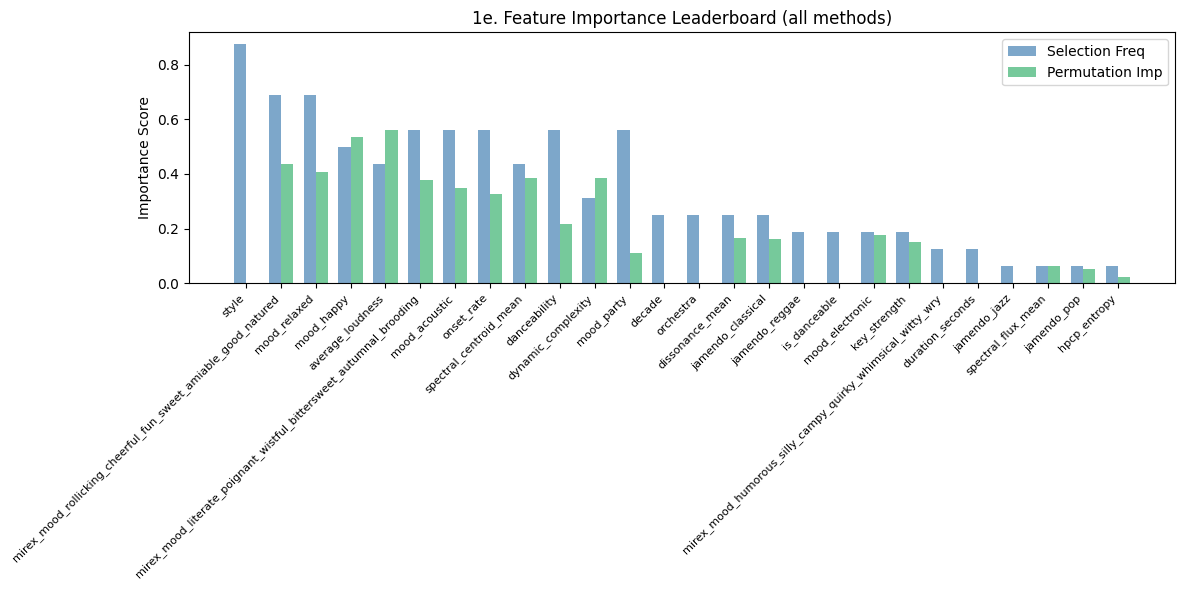

In [10]:
# --- 1e. Aggregated Feature Importance Leaderboard ---

# Determine which features to rank
features_to_rank = TARGET_FEATURES if TARGET_FEATURES else list(all_features_seen) if all_feature_counts else []

if features_to_rank:
    leaderboard = []
    for fname in features_to_rank:
        row = {'feature': fname, 'group': feature_to_group.get(fname, 'unknown')}

        # Selection frequency across all feature-selecting methods (normalized to 0-1)
        total_prompts = len(TEST_PROMPTS)
        freq_scores = []
        for method_name, counts in method_counts.items():
            freq_scores.append(counts.get(fname, 0) / max(total_prompts, 1))
        row['select_freq'] = np.mean(freq_scores) if freq_scores else 0.0

        # Permutation importance
        row['perm_importance'] = avg_importance.get(fname, 0.0)

        # Aggregate score (equal weight to each signal)
        signals = [row['select_freq'], row['perm_importance']]
        valid_signals = [s for s in signals if s > 0]
        row['aggregate_score'] = np.mean(valid_signals) if valid_signals else 0.0

        leaderboard.append(row)

    df_leaderboard = pd.DataFrame(leaderboard).sort_values('aggregate_score', ascending=False)
    df_leaderboard = df_leaderboard.reset_index(drop=True)
    df_leaderboard.index = df_leaderboard.index + 1  # 1-based ranking
    df_leaderboard.index.name = 'rank'

    print('=== Feature Importance Leaderboard ===')
    print(df_leaderboard.to_string(float_format='%.4f'))

    # Classify features into tiers
    n_features = len(df_leaderboard)
    q1 = n_features // 4
    df_leaderboard['tier'] = 'drop_candidate'
    df_leaderboard.loc[df_leaderboard.index <= n_features - q1, 'tier'] = 'nice_to_have'
    df_leaderboard.loc[df_leaderboard.index <= q1, 'tier'] = 'essential'

    print('\n\n=== Feature Tiers ===')
    for tier in ['essential', 'nice_to_have', 'drop_candidate']:
        features = df_leaderboard[df_leaderboard['tier'] == tier]['feature'].tolist()
        print(f'  {tier.upper():15s}: {features}')

    # Visualization: grouped bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    features = df_leaderboard['feature'].tolist()
    x = range(len(features))
    width = 0.35

    ax.bar([i - width/2 for i in x], df_leaderboard['select_freq'],
           width, label='Selection Freq', color='steelblue', alpha=0.7)
    ax.bar([i + width/2 for i in x], df_leaderboard['perm_importance'],
           width, label='Permutation Imp', color='mediumseagreen', alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Importance Score')
    ax.set_title('1e. Feature Importance Leaderboard (all methods)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('1e. No features to rank — run method notebooks first')

---
## 2. Cross-Method Comparison

Compare all methods side-by-side: agreement, rank correlation, latency, and qualitative results.

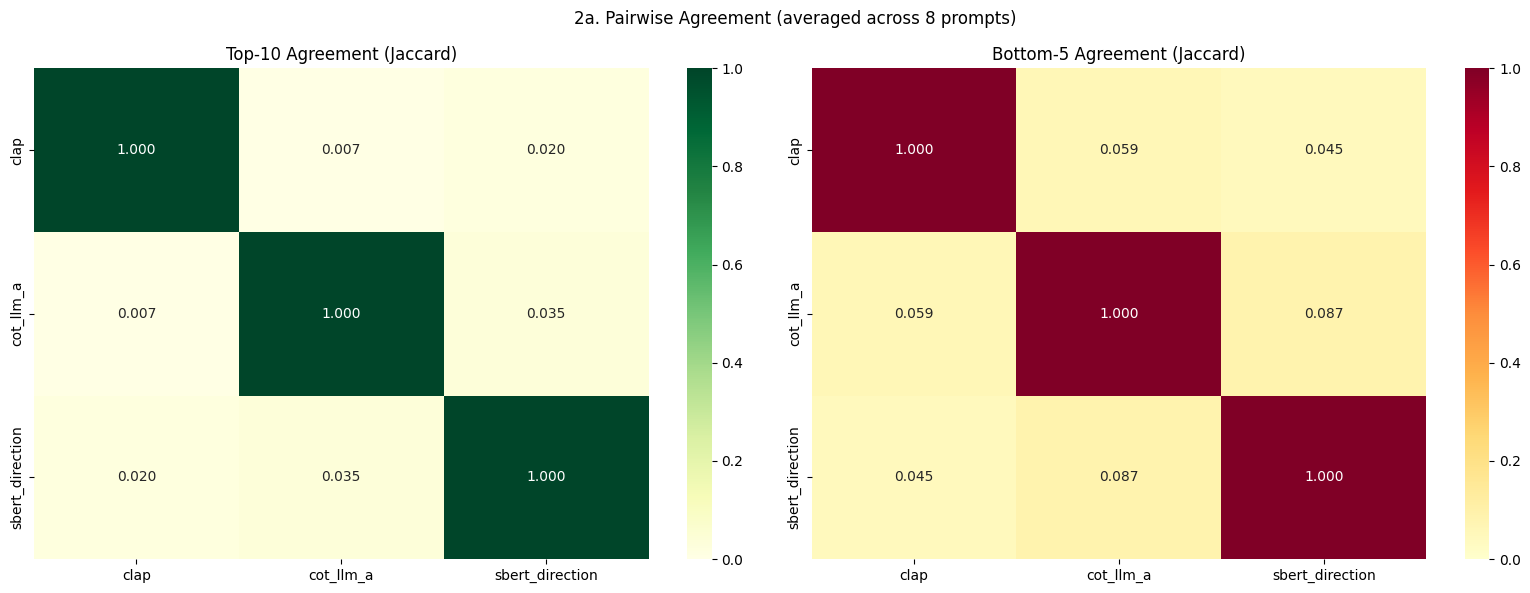

In [11]:
# --- 2a. Agreement@K: Jaccard similarity between methods ---

active_methods = {name: results for name, results in ALL_RESULTS.items() if results}
method_names = list(active_methods.keys())

if len(method_names) >= 2:
    # Pairwise Jaccard for each prompt
    agreement_matrix = np.zeros((len(method_names), len(method_names)))

    for i, m1 in enumerate(method_names):
        for j, m2 in enumerate(method_names):
            if i == j:
                agreement_matrix[i, j] = 1.0
                continue
            jaccards = []
            for pi in range(len(TEST_PROMPTS)):
                if pi < len(active_methods[m1]) and pi < len(active_methods[m2]):
                    songs1 = set(s['filename'] for s in active_methods[m1][pi]['top_k_songs'][:TOP_K])
                    songs2 = set(s['filename'] for s in active_methods[m2][pi]['top_k_songs'][:TOP_K])
                    if songs1 | songs2:
                        jaccards.append(len(songs1 & songs2) / len(songs1 | songs2))
            agreement_matrix[i, j] = np.mean(jaccards) if jaccards else 0.0

    # Bottom-K agreement
    bottom_agreement = np.zeros((len(method_names), len(method_names)))
    for i, m1 in enumerate(method_names):
        for j, m2 in enumerate(method_names):
            if i == j:
                bottom_agreement[i, j] = 1.0
                continue
            jaccards = []
            for pi in range(len(TEST_PROMPTS)):
                if pi < len(active_methods[m1]) and pi < len(active_methods[m2]):
                    songs1 = set(s['filename'] for s in active_methods[m1][pi].get('bottom_k_songs', []))
                    songs2 = set(s['filename'] for s in active_methods[m2][pi].get('bottom_k_songs', []))
                    if songs1 | songs2:
                        jaccards.append(len(songs1 & songs2) / len(songs1 | songs2))
            bottom_agreement[i, j] = np.mean(jaccards) if jaccards else 0.0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(agreement_matrix, annot=True, fmt='.3f', cmap='YlGn',
                xticklabels=method_names, yticklabels=method_names, ax=ax1,
                vmin=0, vmax=1)
    ax1.set_title(f'Top-{TOP_K} Agreement (Jaccard)')
    sns.heatmap(bottom_agreement, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=method_names, yticklabels=method_names, ax=ax2,
                vmin=0, vmax=1)
    ax2.set_title(f'Bottom-{BOTTOM_K} Agreement (Jaccard)')
    plt.suptitle(f'2a. Pairwise Agreement (averaged across {len(TEST_PROMPTS)} prompts)')
    plt.tight_layout()
    plt.show()
else:
    print(f'Only {len(method_names)} method(s) have results — need >=2 for comparison')

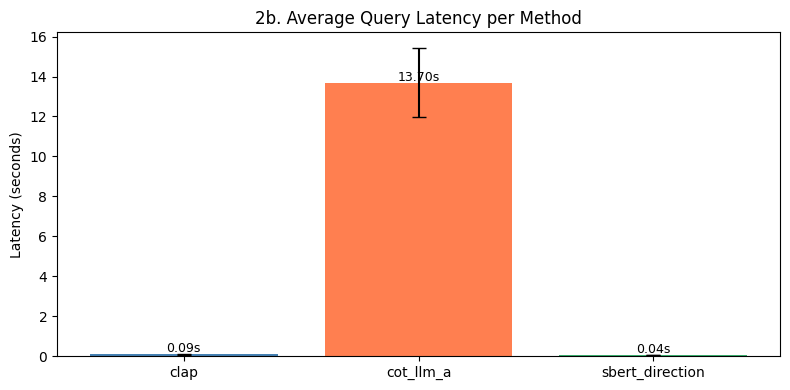

In [12]:
# --- 2b. Latency comparison ---

latencies = {}
for name, results in active_methods.items():
    lats = [r['metadata'].get('latency_seconds', 0) for r in results]
    latencies[name] = {'mean': np.mean(lats), 'std': np.std(lats), 'values': lats}

if latencies:
    fig, ax = plt.subplots(figsize=(8, 4))
    names = list(latencies.keys())
    means = [latencies[n]['mean'] for n in names]
    stds = [latencies[n]['std'] for n in names]
    bars = ax.bar(names, means, yerr=stds, capsize=5,
                  color=['steelblue', 'coral', 'mediumseagreen', 'goldenrod'][:len(names)])
    ax.set_ylabel('Latency (seconds)')
    ax.set_title('2b. Average Query Latency per Method')
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{mean:.2f}s', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

In [13]:
# --- 2c. Qualitative: Side-by-side top-5 for each prompt ---

for pi, prompt in enumerate(TEST_PROMPTS):
    print(f'\n{"="*80}')
    print(f'PROMPT: "{prompt}"')
    print(f'{"="*80}')

    for method_name, results in active_methods.items():
        if pi >= len(results):
            continue
        result = results[pi]
        print(f'\n  [{method_name.upper()}]')
        for rank, song in enumerate(result['top_k_songs'][:5], 1):
            expl = song.get('explanation', '')[:60]
            print(f'    {rank}. {song["score"]:.4f}  {song["filename"][:40]:40s}  {expl}')

        # Show feature ranges if available
        ranges = result.get('feature_ranges_used', {})
        if ranges:
            _fmt = lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else str(x)
            range_summary = ', '.join(f'{k}=[{_fmt(v.get("min",0))},{_fmt(v.get("max",0))}]' for k, v in list(ranges.items())[:5])
            print(f'    Ranges: {range_summary}{"..." if len(ranges) > 5 else ""}')

        # Worst matches
        bottom = result.get('bottom_k_songs', [])
        if bottom:
            print(f'    --- WORST MATCHES ---')
            for rank, song in enumerate(bottom[:5], 1):
                print(f'    {rank}. {song["score"]:.4f}  {song["filename"][:40]:40s}')


PROMPT: "energetic tango with strong rhythm for experienced dancers"

  [CLAP]
    1. 0.3680  23 no me extraña.mp3                      CLAP similarity score: 0.3680
    2. 0.3611  27 clavel.mp3                             CLAP similarity score: 0.3611
    3. 0.3600  13 valsecito criollo.mp3                  CLAP similarity score: 0.3600
    4. 0.3581  14 quejas de bandoneon.mp3                CLAP similarity score: 0.3581
    5. 0.3486  12 francia.mp3                            CLAP similarity score: 0.3486
    --- WORST MATCHES ---
    1. -0.0712  04 y la perdi.mp3                       
    2. -0.0610  09 barro.mp3                            
    3. -0.0577  04 dandy.mp3                            
    4. -0.0471  19 motivo sentimental.mp3               
    5. -0.0457  08 volver a vernos.mp3                  

  [COT_LLM_A]
    1. 1.0000  04 seamos amigos.mp3                      An energetic tango with strong rhythm for experienced dancer
    2. 0.9898  29 tres esquinas.mp3      

In [14]:
# --- 2d. Top vs Bottom Validation Summary ---
# For each prompt, compare best #1 vs worst #1 per method to validate scoring

print('TOP vs BOTTOM VALIDATION')
print('If scoring works, worst matches should be obviously wrong for each prompt.')
print()

header = '  {:15s}  {:>8s}  {:35s}  {:>8s}  {:35s}  {:>6s}'.format(
    'Method', 'Best', 'Best Song', 'Worst', 'Worst Song', 'Gap')
divider = '  ' + '-'*15 + '  ' + '-'*8 + '  ' + '-'*35 + '  ' + '-'*8 + '  ' + '-'*35 + '  ' + '-'*6

for pi, prompt in enumerate(TEST_PROMPTS):
    print()
    print('PROMPT: "{}"'.format(prompt))
    print(header)
    print(divider)
    for method_name, results in active_methods.items():
        if pi >= len(results):
            continue
        result = results[pi]
        best = result['top_k_songs'][0] if result['top_k_songs'] else None
        worst_list = result.get('bottom_k_songs', [])
        worst = worst_list[-1] if worst_list else None
        if best and worst:
            gap = best['score'] - worst['score']
            print('  {:15s}  {:8.4f}  {:35s}  {:8.4f}  {:35s}  {:6.4f}'.format(
                method_name, best['score'], best['filename'][:35],
                worst['score'], worst['filename'][:35], gap))


TOP vs BOTTOM VALIDATION
If scoring works, worst matches should be obviously wrong for each prompt.


PROMPT: "energetic tango with strong rhythm for experienced dancers"
  Method               Best  Best Song                               Worst  Worst Song                              Gap
  ---------------  --------  -----------------------------------  --------  -----------------------------------  ------
  clap               0.3680  23 no me extraña.mp3                  -0.0457  08 volver a vernos.mp3               0.4137
  cot_llm_a          1.0000  04 seamos amigos.mp3                   0.6225  29 entre sueños.mp3                  0.3775
  sbert_direction    1.0000  29 soy un porteño.mp3                  0.1247  22 buscandote.mp3                    0.8753

PROMPT: "melancholic and slow, perfect for a late-night vals"
  Method               Best  Best Song                               Worst  Worst Song                              Gap
  ---------------  --------  -----------------

In [15]:
# --- 2e. Prompt × Method heatmap: top-1 agreement ---

if len(active_methods) >= 2:
    # For each prompt, which method's #1 song is the same?
    top1_matrix = {}
    for method_name, results in active_methods.items():
        top1_matrix[method_name] = []
        for result in results:
            top1 = result['top_k_songs'][0]['filename'] if result['top_k_songs'] else ''
            top1_matrix[method_name].append(top1)

    df_top1 = pd.DataFrame(top1_matrix, index=[p[:30] + '...' for p in TEST_PROMPTS])
    print('Top-1 song per method per prompt:')
    print(df_top1.to_string())

    # Count how many methods agree on top-1
    print('\nTop-1 agreement count per prompt:')
    for i, prompt in enumerate(TEST_PROMPTS):
        songs = [top1_matrix[m][i] for m in method_names if i < len(top1_matrix[m])]
        from collections import Counter
        counts = Counter(songs)
        most_common = counts.most_common(1)[0]
        print(f'  "{prompt[:40]}..." → {most_common[1]}/{len(songs)} agree on "{most_common[0]}"')

Top-1 song per method per prompt:
                                                            clap                        cot_llm_a        sbert_direction
energetic tango with strong rh...           23 no me extraña.mp3             04 seamos amigos.mp3  29 soy un porteño.mp3
melancholic and slow, perfect ...      14 valsecito de antes.mp3        19 motivo sentimental.mp3    14 maria esther.mp3
bright and cheerful milonga wi...            07 de mi barrio.mp3             13 alma dolorida.mp3  18 el entrerriano.mp3
dramatic tango with heavy band...         14 acuerdate de mi.mp3              16 el cocherito.mp3  29 soy un porteño.mp3
smooth and relaxed, good for w...  17 no quiero verte llorar.mp3                   18 pastora.mp3    14 maria esther.mp3
classic golden-age tango from ...           07 a la parrilla.mp3               27 rosa morena.mp3       04 barajando.mp3
a lively vals from the 50s wit...           23 no me extraña.mp3          21 cancion de rango.mp3       28 el torito.mp

## 2f. Cross-Method Feature Selection & Decision Similarity

For each prompt, compare feature selection and song decisions across methods. CLAP does not perform explicit feature selection, so it is N/A for Part 1 but included in Part 2 via its selected songs.

**Part 1 — Feature selection overlap:** Jaccard similarity between the feature sets selected by CoT LLM vs SBERT Direction for the same prompt, plus direction agreement on shared features.

**Part 2 — Decision similarity via feature profiles:** Take the union of all features selected by any feature-selecting method. For each prompt, compare the feature-value profiles of top-K and bottom-K songs selected by *all* methods (including CLAP) on that shared feature set. This reveals whether different methods/reasoning paths lead to similar song choices in feature space.

=== Part 1: Feature Selection Overlap (per prompt) ===

                                            prompt  cot_features  sbert_features  shared  union  jaccard  direction_agreement
energetic tango with strong rhythm for experienced            10               8       2     16    0.125                1.000
melancholic and slow, perfect for a late-night val            10               8       5     13    0.385                0.600
     bright and cheerful milonga with clear melody            10               8       4     14    0.286                0.500
 dramatic tango with heavy bandoneon and dark mood            10               8       4     14    0.286                0.500
 smooth and relaxed, good for warming up the floor            10               8       6     12    0.500                0.667
classic golden-age tango from the 40s, warm and no            10               8       3     15    0.200                0.667
a lively vals from the 50s with a strong orchestra            

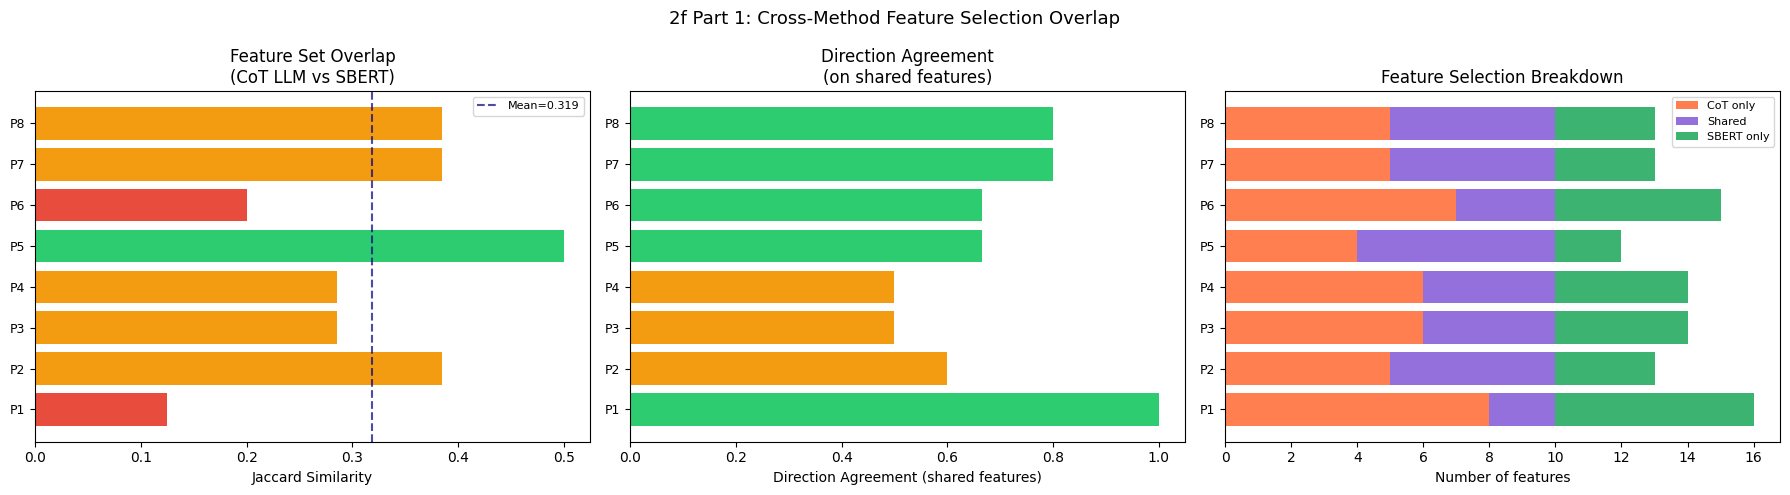


--- Per-prompt feature detail ---

P1: "energetic tango with strong rhythm for experienced dancers"
  Shared (2): danceability, onset_rate
  CoT only (8): average_loudness, dynamic_complexity, key_strength, mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured, mood_happy, mood_relaxed, spectral_centroid_mean, spectral_flux_mean
  SBERT only (6): duration_seconds, is_danceable, jamendo_reggae, mood_party, orchestra, style

P2: "melancholic and slow, perfect for a late-night vals"
  Shared (5): mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding, mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured, mood_acoustic, mood_relaxed, style
  CoT only (5): average_loudness, dynamic_complexity, mood_electronic, mood_happy, onset_rate
  SBERT only (3): dissonance_mean, mirex_mood_humorous_silly_campy_quirky_whimsical_witty_wry, mood_party

P3: "bright and cheerful milonga with clear melody"
  Shared (4): mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natur

In [16]:
# --- 2f Part 1: Feature Selection Overlap (CoT LLM vs SBERT Direction) ---
# CLAP is N/A here — it does not perform explicit feature selection.

feature_methods = {
    name: results for name, results in ALL_RESULTS.items()
    if results and name in ('cot_llm_a', 'sbert_direction')
}

if len(feature_methods) >= 2:
    cot_results = ALL_RESULTS.get('cot_llm_a', [])
    sbert_results = ALL_RESULTS.get('sbert_direction', [])
    n_prompts = min(len(cot_results), len(sbert_results), len(TEST_PROMPTS))

    rows = []
    for pi in range(n_prompts):
        prompt = TEST_PROMPTS[pi]
        cot_feats = set(cot_results[pi].get('feature_ranges_used', {}).keys())
        sbert_feats = set(sbert_results[pi].get('feature_ranges_used', {}).keys())

        union = cot_feats | sbert_feats
        inter = cot_feats & sbert_feats
        jaccard = len(inter) / len(union) if union else 0.0

        # Direction agreement on shared features
        n_agree = 0
        n_shared = len(inter)
        for fname in inter:
            cot_dir = cot_results[pi]['feature_ranges_used'][fname].get('direction', '')
            sbert_dir = sbert_results[pi]['feature_ranges_used'][fname].get('direction', '')
            cot_higher = cot_dir in ('higher_better', 1, '1')
            sbert_higher = sbert_dir in ('higher_better', 1, '1')
            if cot_higher == sbert_higher:
                n_agree += 1
        dir_agreement = n_agree / n_shared if n_shared > 0 else float('nan')

        rows.append({
            'prompt': prompt[:50],
            'cot_features': len(cot_feats),
            'sbert_features': len(sbert_feats),
            'shared': n_shared,
            'union': len(union),
            'jaccard': jaccard,
            'direction_agreement': dir_agreement,
        })

    df_overlap = pd.DataFrame(rows)

    # --- Summary table ---
    print('=== Part 1: Feature Selection Overlap (per prompt) ===\n')
    print(df_overlap.to_string(index=False, float_format='%.3f'))
    print(f'\nMean Jaccard:            {df_overlap["jaccard"].mean():.3f}')
    print(f'Mean direction agreement: {df_overlap["direction_agreement"].mean():.3f}')

    # --- Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Jaccard per prompt
    colors = ['#2ecc71' if j > 0.4 else '#f39c12' if j > 0.2 else '#e74c3c'
              for j in df_overlap['jaccard']]
    axes[0].barh(range(n_prompts), df_overlap['jaccard'], color=colors)
    axes[0].set_yticks(range(n_prompts))
    axes[0].set_yticklabels([f'P{i+1}' for i in range(n_prompts)], fontsize=9)
    axes[0].set_xlabel('Jaccard Similarity')
    axes[0].set_title('Feature Set Overlap\n(CoT LLM vs SBERT)')
    axes[0].axvline(x=df_overlap['jaccard'].mean(), color='navy', linestyle='--',
                    alpha=0.7, label=f'Mean={df_overlap["jaccard"].mean():.3f}')
    axes[0].legend(fontsize=8)

    # 2) Direction agreement per prompt
    dir_vals = df_overlap['direction_agreement'].fillna(0)
    dir_colors = ['#2ecc71' if d > 0.6 else '#f39c12' if d > 0.3 else '#e74c3c'
                  for d in dir_vals]
    axes[1].barh(range(n_prompts), dir_vals, color=dir_colors)
    axes[1].set_yticks(range(n_prompts))
    axes[1].set_yticklabels([f'P{i+1}' for i in range(n_prompts)], fontsize=9)
    axes[1].set_xlabel('Direction Agreement (shared features)')
    axes[1].set_title('Direction Agreement\n(on shared features)')

    # 3) Venn-style stacked bar: cot-only | shared | sbert-only
    cot_only = df_overlap['cot_features'] - df_overlap['shared']
    sbert_only = df_overlap['sbert_features'] - df_overlap['shared']
    y = range(n_prompts)
    axes[2].barh(y, cot_only, color='coral', label='CoT only')
    axes[2].barh(y, df_overlap['shared'], left=cot_only, color='mediumpurple', label='Shared')
    axes[2].barh(y, sbert_only, left=cot_only + df_overlap['shared'],
                 color='mediumseagreen', label='SBERT only')
    axes[2].set_yticks(range(n_prompts))
    axes[2].set_yticklabels([f'P{i+1}' for i in range(n_prompts)], fontsize=9)
    axes[2].set_xlabel('Number of features')
    axes[2].set_title('Feature Selection Breakdown')
    axes[2].legend(fontsize=8)

    plt.suptitle('2f Part 1: Cross-Method Feature Selection Overlap', fontsize=13)
    plt.tight_layout()
    plt.show()

    # --- Per-prompt detail: which features are shared, which are unique ---
    print('\n--- Per-prompt feature detail ---')
    for pi in range(n_prompts):
        prompt = TEST_PROMPTS[pi]
        cot_feats = set(cot_results[pi].get('feature_ranges_used', {}).keys())
        sbert_feats = set(sbert_results[pi].get('feature_ranges_used', {}).keys())
        shared = cot_feats & sbert_feats
        print(f'\nP{pi+1}: "{prompt[:60]}"')
        if shared:
            print(f'  Shared ({len(shared)}): {", ".join(sorted(shared))}')
        cot_only_set = cot_feats - sbert_feats
        sbert_only_set = sbert_feats - cot_feats
        if cot_only_set:
            print(f'  CoT only ({len(cot_only_set)}): {", ".join(sorted(cot_only_set))}')
        if sbert_only_set:
            print(f'  SBERT only ({len(sbert_only_set)}): {", ".join(sorted(sbert_only_set))}')
else:
    print('Need both cot_llm_a and sbert_direction results for Part 1')

In [17]:
# --- 2f Part 2: Decision Similarity via Feature Profiles ---
# For each prompt, gather the union of features selected by CoT + SBERT,
# then compare feature-value profiles of songs selected by ALL methods (incl. CLAP).

if len(feature_methods) >= 2 and len(active_methods) >= 2:
    from sklearn.metrics.pairwise import cosine_similarity as cos_sim
    from sklearn.preprocessing import StandardScaler

    n_prompts = min(len(TEST_PROMPTS),
                    *[len(r) for r in active_methods.values()])

    # --- Build per-prompt union feature set from CoT + SBERT ---
    prompt_feature_unions = []
    for pi in range(n_prompts):
        union_feats = set()
        for mname in ('cot_llm_a', 'sbert_direction'):
            if mname in ALL_RESULTS and pi < len(ALL_RESULTS[mname]):
                union_feats |= set(ALL_RESULTS[mname][pi].get('feature_ranges_used', {}).keys())
        # Keep only numeric features present in df_merged
        union_feats = sorted(f for f in union_feats
                             if f in df_merged.columns
                             and df_merged[f].dtype in ['float64', 'float32', 'int64'])
        prompt_feature_unions.append(union_feats)

    # --- For each prompt, extract feature profiles of top/bottom songs per method ---
    similarity_rows = []
    profile_data = {}  # prompt_idx -> {union_feats, top_profiles, bottom_profiles}

    for pi in range(n_prompts):
        union_feats = prompt_feature_unions[pi]
        if len(union_feats) < 2:
            continue

        # Standardize features across the full catalog for fair comparison
        feat_df = df_merged[union_feats].copy().fillna(df_merged[union_feats].mean())
        scaler = StandardScaler()
        feat_scaled = pd.DataFrame(
            scaler.fit_transform(feat_df),
            index=df_merged.index, columns=union_feats
        )

        # Gather top-K and bottom-K song filenames per method
        method_top_songs = {}
        method_bottom_songs = {}
        for mname, mresults in active_methods.items():
            if pi >= len(mresults):
                continue
            top_fnames = [s['filename'] for s in mresults[pi]['top_k_songs'][:TOP_K]]
            bottom_fnames = [s['filename'] for s in mresults[pi].get('bottom_k_songs', [])]
            method_top_songs[mname] = top_fnames
            method_bottom_songs[mname] = bottom_fnames

        # Compute mean feature profile per method (top songs)
        method_profiles_top = {}
        method_profiles_bottom = {}
        for mname in active_methods:
            if mname not in method_top_songs:
                continue
            mask_top = df_merged['filename'].isin(method_top_songs[mname])
            if mask_top.sum() > 0:
                method_profiles_top[mname] = feat_scaled.loc[mask_top].mean().values
            if mname in method_bottom_songs and method_bottom_songs[mname]:
                mask_bot = df_merged['filename'].isin(method_bottom_songs[mname])
                if mask_bot.sum() > 0:
                    method_profiles_bottom[mname] = feat_scaled.loc[mask_bot].mean().values

        # Pairwise cosine similarity between method profiles (top songs)
        mnames_top = list(method_profiles_top.keys())
        for i, m1 in enumerate(mnames_top):
            for j, m2 in enumerate(mnames_top):
                if i >= j:
                    continue
                sim = cos_sim(
                    method_profiles_top[m1].reshape(1, -1),
                    method_profiles_top[m2].reshape(1, -1)
                )[0, 0]
                similarity_rows.append({
                    'prompt_idx': pi,
                    'prompt': TEST_PROMPTS[pi][:50],
                    'method_a': m1,
                    'method_b': m2,
                    'pool': 'top_k',
                    'cosine_sim': sim,
                    'n_features': len(union_feats),
                })

        # Pairwise cosine similarity between method profiles (bottom songs)
        mnames_bot = list(method_profiles_bottom.keys())
        for i, m1 in enumerate(mnames_bot):
            for j, m2 in enumerate(mnames_bot):
                if i >= j:
                    continue
                sim = cos_sim(
                    method_profiles_bottom[m1].reshape(1, -1),
                    method_profiles_bottom[m2].reshape(1, -1)
                )[0, 0]
                similarity_rows.append({
                    'prompt_idx': pi,
                    'prompt': TEST_PROMPTS[pi][:50],
                    'method_a': m1,
                    'method_b': m2,
                    'pool': 'bottom_k',
                    'cosine_sim': sim,
                    'n_features': len(union_feats),
                })

        profile_data[pi] = {
            'union_feats': union_feats,
            'top_profiles': method_profiles_top,
            'bottom_profiles': method_profiles_bottom,
        }

    df_sim = pd.DataFrame(similarity_rows)
    print('=== Part 2: Decision Similarity via Feature Profiles ===\n')
    print(df_sim.to_string(index=False, float_format='%.3f'))
else:
    print('Need at least 2 methods with results for Part 2')
    df_sim = pd.DataFrame()

=== Part 2: Decision Similarity via Feature Profiles ===

 prompt_idx                                             prompt  method_a        method_b     pool  cosine_sim  n_features
          0 energetic tango with strong rhythm for experienced      clap       cot_llm_a    top_k       0.412          14
          0 energetic tango with strong rhythm for experienced      clap sbert_direction    top_k       0.286          14
          0 energetic tango with strong rhythm for experienced cot_llm_a sbert_direction    top_k       0.731          14
          0 energetic tango with strong rhythm for experienced      clap       cot_llm_a bottom_k       0.565          14
          0 energetic tango with strong rhythm for experienced      clap sbert_direction bottom_k       0.737          14
          0 energetic tango with strong rhythm for experienced cot_llm_a sbert_direction bottom_k       0.755          14
          1 melancholic and slow, perfect for a late-night val      clap       cot_llm_a

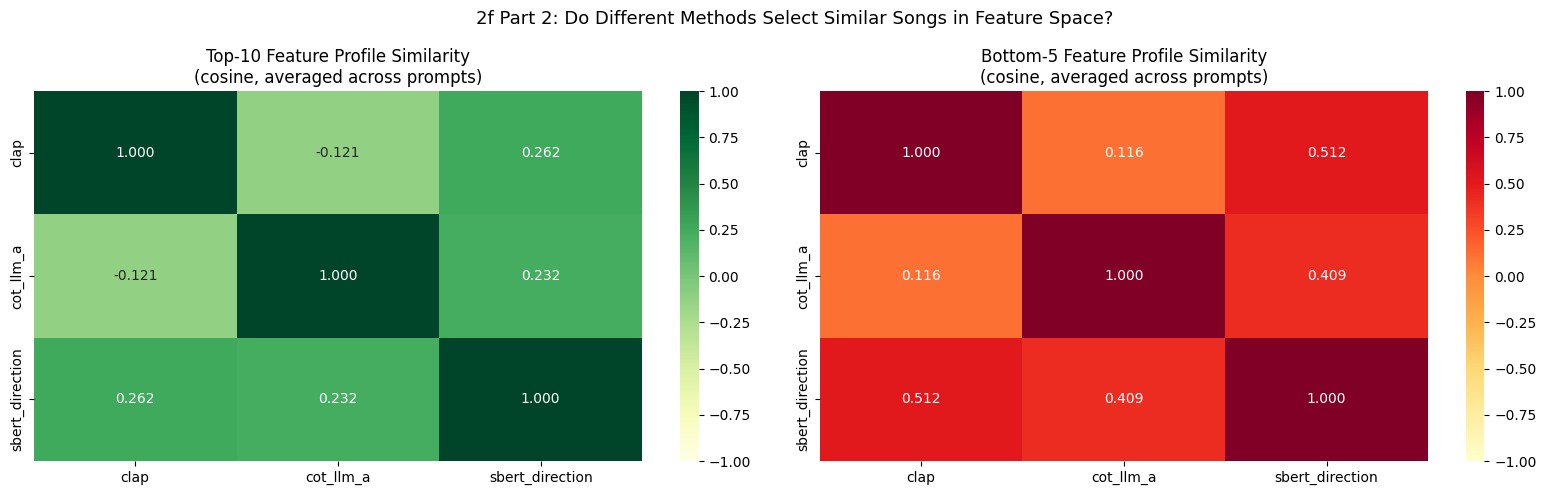

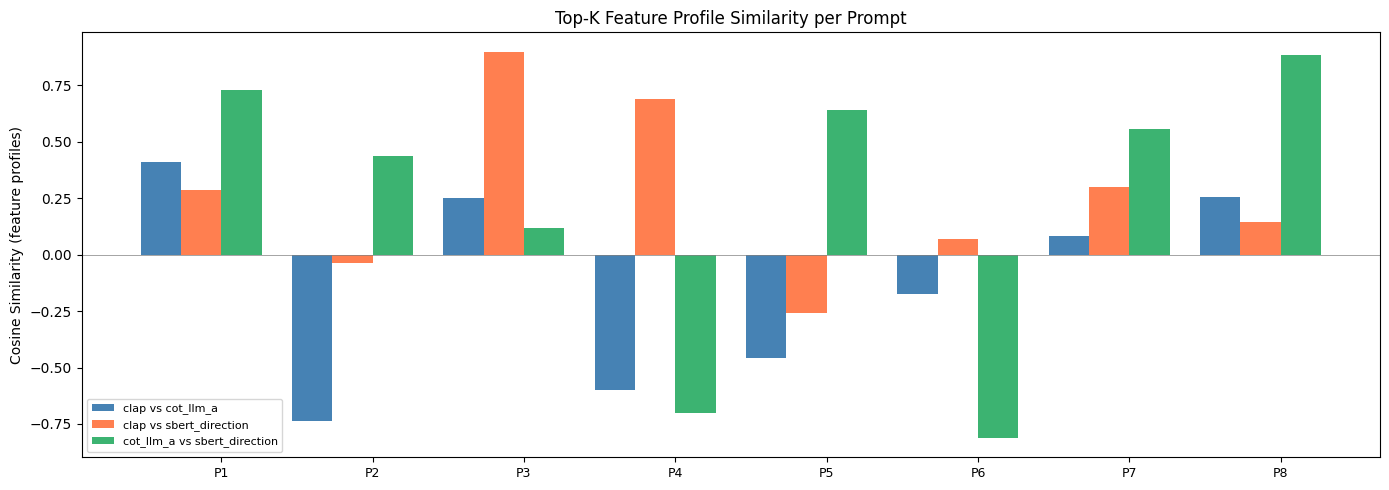


=== Summary ===

TOP_K profile similarity:
  clap vs cot_llm_a: mean=-0.121, std=0.436, min=-0.736, max=0.412
  clap vs sbert_direction: mean=0.262, std=0.379, min=-0.257, max=0.900
  cot_llm_a vs sbert_direction: mean=0.232, std=0.651, min=-0.812, max=0.884

BOTTOM_K profile similarity:
  clap vs cot_llm_a: mean=0.116, std=0.608, min=-0.757, max=0.893
  clap vs sbert_direction: mean=0.512, std=0.439, min=-0.140, max=0.951
  cot_llm_a vs sbert_direction: mean=0.409, std=0.636, min=-0.696, max=0.920


In [18]:
# --- 2f Part 2 Visualization ---

if not df_sim.empty:
    method_pairs = df_sim[['method_a', 'method_b']].drop_duplicates().values.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # --- Top-K profile similarity heatmap (averaged across prompts) ---
    df_top = df_sim[df_sim['pool'] == 'top_k']
    all_methods_in_sim = sorted(set(df_top['method_a']) | set(df_top['method_b']))
    n_m = len(all_methods_in_sim)
    sim_matrix_top = np.ones((n_m, n_m))
    for _, row in df_top.groupby(['method_a', 'method_b'])['cosine_sim'].mean().items():
        i = all_methods_in_sim.index(_[0])
        j = all_methods_in_sim.index(_[1])
        sim_matrix_top[i, j] = row
        sim_matrix_top[j, i] = row

    sns.heatmap(sim_matrix_top, annot=True, fmt='.3f', cmap='YlGn',
                xticklabels=all_methods_in_sim, yticklabels=all_methods_in_sim,
                ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title(f'Top-{TOP_K} Feature Profile Similarity\n(cosine, averaged across prompts)')

    # --- Bottom-K profile similarity heatmap ---
    df_bot = df_sim[df_sim['pool'] == 'bottom_k']
    sim_matrix_bot = np.ones((n_m, n_m))
    for _, row in df_bot.groupby(['method_a', 'method_b'])['cosine_sim'].mean().items():
        i = all_methods_in_sim.index(_[0])
        j = all_methods_in_sim.index(_[1])
        sim_matrix_bot[i, j] = row
        sim_matrix_bot[j, i] = row

    sns.heatmap(sim_matrix_bot, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=all_methods_in_sim, yticklabels=all_methods_in_sim,
                ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title(f'Bottom-{BOTTOM_K} Feature Profile Similarity\n(cosine, averaged across prompts)')

    plt.suptitle('2f Part 2: Do Different Methods Select Similar Songs in Feature Space?', fontsize=13)
    plt.tight_layout()
    plt.show()

    # --- Per-prompt breakdown: bar chart of pairwise similarities ---
    df_top_only = df_sim[df_sim['pool'] == 'top_k'].copy()
    df_top_only['pair'] = df_top_only['method_a'] + ' vs ' + df_top_only['method_b']
    pairs = df_top_only['pair'].unique()

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(n_prompts)
    width = 0.8 / len(pairs)
    pair_colors = ['steelblue', 'coral', 'mediumseagreen', 'goldenrod', 'orchid', 'grey']

    for k, pair in enumerate(pairs):
        subset = df_top_only[df_top_only['pair'] == pair].sort_values('prompt_idx')
        ax.bar(x + k * width, subset['cosine_sim'].values, width,
               label=pair, color=pair_colors[k % len(pair_colors)])

    ax.set_xticks(x + width * len(pairs) / 2)
    ax.set_xticklabels([f'P{i+1}' for i in range(n_prompts)], fontsize=9)
    ax.set_ylabel('Cosine Similarity (feature profiles)')
    ax.set_title('Top-K Feature Profile Similarity per Prompt')
    ax.legend(fontsize=8)
    ax.axhline(y=0, color='grey', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    # --- Summary statistics ---
    print('\n=== Summary ===')
    for pool in ('top_k', 'bottom_k'):
        sub = df_sim[df_sim['pool'] == pool]
        print(f'\n{pool.upper()} profile similarity:')
        for (ma, mb), grp in sub.groupby(['method_a', 'method_b']):
            print(f'  {ma} vs {mb}: mean={grp["cosine_sim"].mean():.3f}, '
                  f'std={grp["cosine_sim"].std():.3f}, '
                  f'min={grp["cosine_sim"].min():.3f}, '
                  f'max={grp["cosine_sim"].max():.3f}')

---
## 3. Summary & Next Steps

### Methods Compared

| Method | Type | Requires API? | Latency | Explainability | Personalizable? |
|--------|------|---------------|---------|----------------|------------------|
| **CLAP** | Pretrained embedding similarity | No | Medium (~2s with audio, fast with proxy) | Low (score only) | No |
| **CoT LLM** | Single LLM call: select features + ranges | Yes | High (~3-5s) | High (reasoning + ranges) | No |
| **SBERT Direction** | Semantic select + range mapping | No | Fast (<0.5s) | High (feature weights + ranges) | No |
| **Small Model** | Dual-head MLP: text → mask + ranges | No (after training) | Very low (<0.01s) | Medium (mask + ranges) | **Yes** (fine-tunable) |

### Key Findings

1. **Feature importance:** The leaderboard in Section 1e identifies which features drive song matching across all methods. Essential features (top quartile) should be kept in the production Track schema.

2. **Method complementarity:** CLAP captures holistic audio similarity, while CoT and SBERT methods provide interpretable feature-level matching. The small model (once trained) can bridge both — learning feature importance from LLM outputs.

3. **Production recommendation:**
   - **Fast path (no API):** SBERT direction for feature selection → `score_songs_by_ranges()` for ranking
   - **Quality path (with API):** CoT LLM for best reasoning and explanations
   - **Hybrid:** Use SBERT as default, fall back to LLM when user requests explanation

### Next Steps

- [ ] Train small model (02d) once sufficient LLM-labeled data is generated
- [ ] Integrate best method into LangGraph agent (WP-06) as a tool
- [ ] Benchmark on full catalog once WP-02 extraction is complete
